# Лабораторная 6. Моделирование Variance Gamma случайного процесса.

## 1. Определение Variance Gamma случайного процесса.

Variance Gamma процесс можно представить как подстановочное Броуновское движение. Формально, пусть $W(t)$ - стандартный Винеровский процесс, а $G(t)$ - гамма-процесс. Тогда Variance Gamma процесс $VG(t)$ представим в виде: $VG(t) = \theta G(t) + \sigma W(G(t))$, где: $\theta$ - параметр асимметрии, $\sigma$ - параметр волатильности, $\Delta G(t) \sim \text{Gamma}(\frac{\Delta t}{\nu}, \nu)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Алгоритм моделирования

Для моделирования Variance Gamma случайных величин нужно представить случайные величины Variance Gamma распределения как масштабную смесь нормальных распределений с гамма-смешивающей переменной: $X = \theta G + \sigma \sqrt{G} Z$, где $G \sim \Gamma(\frac{t}{\nu}, \nu)$ и $Z \sim \mathcal{N}(0, 1)$.

В свою очередь для моделирования Variance Gamma процесса для каждого отрезка времени $\frac{T}{N}$ смоделируем случайную величину, имеющую Variance Gamma распределение, а затем посчитаем их кумулянтную сумму.

$T$ - конечное время, $N$ - шаг, $\Delta t = T/N$
1. Сгенерировать $N$ независимых Gamma случайных величин: $\Delta G_i \sim \text{Gamma}(\frac{\Delta t}{\nu}, \nu)$.
2. Сгенерировать $N$ независимых стандартных нормальных случайных величин: $Z_i \sim \mathcal{N}(0,1)$.
3. Вычислить приращения VG процесса как случайную величину VG: $\Delta X_i = \theta \Delta G_i + \sigma \sqrt{\Delta G_i} Z_i$.
4. Вычислить кумулянтную сумму случайных величин.

И так для каждого пути.

In [ ]:
def simulate_vg_rv(t: float,
         sigma: float, theta: float, nu: float, size=(1, 1))->np.ndarray:
    G = np.random.gamma(t / nu, nu, size=size)
    Z = np.random.normal(0, 1, size=size)
    VG = theta * G + sigma * np.sqrt(G) * Z
    return VG

def simulate_vg_process(T=1,
         N=1000, n_paths=1, theta=1., sigma=1., nu=1., seed=42):
    dt = T / N
    np.random.seed(seed)
    
    random_variables = simulate_vg_rv(dt, 
                         sigma, theta, nu, size=(n_paths, N))

    process = np.cumsum(random_variables, axis=1)
    process = np.concatenate([np.zeros((n_paths, 1)), process], axis=1)
    time_net = np.linspace(0, T, N+1)
    return time_net, process

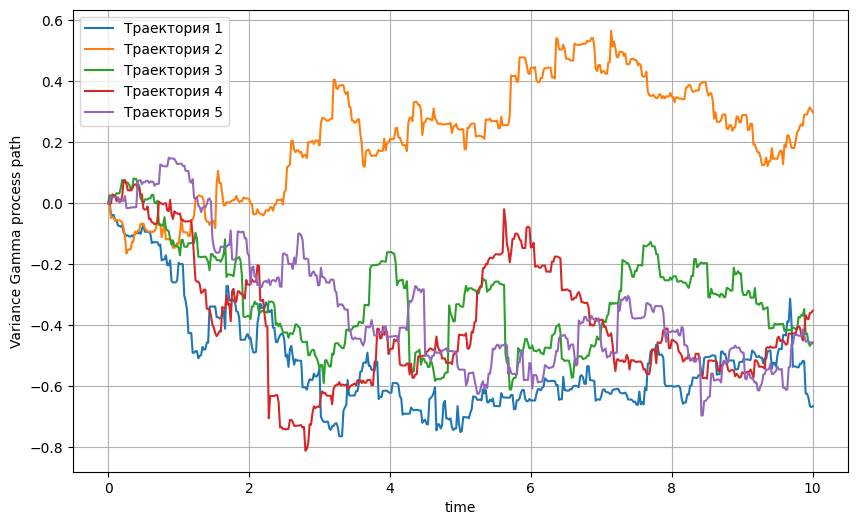

In [ ]:
t, w = simulate_vg_process(T=10, N=500,
             n_paths=5, seed=42, sigma=0.2, theta=0, nu=0.1)

plt.figure(figsize=(10, 6))
for i in range(w.shape[0]):
    plt.plot(t, w[i], label=f'Траектория {i+1}')

plt.xlabel('time')
plt.ylabel('Variance Gamma process path')
plt.grid()
plt.legend()
plt.show()